In [34]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from scipy import stats

# Load dataset
df = pd.read_csv('student_admission_record_dirty.csv')

In [2]:
# 1. Tampilkan rata-rata, standar deviasi, nilai minimum, nilai maksimum, Q1, Q2, dan Q3 dari attribute bertipe angka.
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols].describe() 

,Age,Admission Test Score,High School Percentage
count,147.000000,146.000000,146.000000
mean,19.680272,77.657534,75.684726
std,4.540512,16.855343,17.368014
min,-1.000000,-5.000000,-10.000000
25%,18.000000,68.250000,65.052500
50%,20.000000,79.000000,77.545000
75%,22.000000,89.000000,88.312500
max,24.000000,150.000000,110.500000


## Usia:
1. Nilai minimum -1.0 tahun memang tidak mungkin secara logis
2. Standar deviasi 4.54 mengindikasikan variasi yang tinggi
3. Median 20 tahun masuk akal untuk mahasiswa baru
4. Rentang interkuartil 18-22 tahun menunjukkan distribusi normal 

## Admission Test Score:
1. Nilai minimum -5.0 menunjukkan masalah kualitas data
2. Standar deviasi 16.86 menunjukkan variabilitas wajar
3. Nilai maksimum 150 mengindikasikan performa exceptional atau skala tidak standar
4. Median (79) mendekati mean (77.66) menunjukkan distribusi relatif normal 

## High School Percentage:
1. Nilai minimum -10.0% dan maksimum 110.5% tidak valid secara konseptual 
2. Standar deviasi tinggi (17.37) mengkonfirmasi outlier
3. Median lebih tinggi dari Q1 menunjukkan distribusi normal di bagian tengah 

In [3]:
# 2. Tampilkan 10 record pertama dari dataset dengan attribute bertipe angka.
df[numeric_cols].head(10)

,Age,Admission Test Score,High School Percentage
0,24.0,50.0,68.90
1,21.0,99.0,60.73
2,17.0,89.0,NaN
3,17.0,55.0,85.29
4,20.0,65.0,61.13
5,23.0,NaN,NaN
6,18.0,NaN,97.31
7,20.0,82.0,55.67
8,17.0,64.0,NaN
9,18.0,53.0,98.98


#### 1. Terdapat nilai kosong (NaN) pada beberapa record. Dari 10 data yang ditampilkan, 4 di antaranya memiliki data yang hilang. Kolom High School Percentage paling banyak mengalami kekosongan data, diikuti oleh kolom Admission Test Score. Hal ini mengindikasikan masalah dalam proses pengumpulan atau input data.
#### 2. Summary statistik sebelumnya mengungkap adanya nilai-nilai tidak valid seperti usia -1 tahun, nilai tes -5, dan persentase SMA -10% hingga 110.5%. Ini menunjukkan bahwa masalah data yang lebih serius terdapat pada record-record di luar sample ini

In [4]:
# 3. Tampilkan informasi jumlah record, jumlah attribute, nama attribute, jumlah attribute dengan tipe angka.
total_records = df.shape[0]
total_attributes = df.shape[1]
attribute_names = df.columns.tolist()
numeric_count = len(numeric_cols)

print(f"Jumlah record: {total_records}")
print(f"Jumlah atribut: {total_attributes}")
print(f"Nama atribut: {attribute_names}")
print(f"Jumlah atribut numerik: {numeric_count}")

Jumlah record: 157
Jumlah atribut: 7
Nama atribut: ['Name', 'Age', 'Gender', 'Admission Test Score', 'High School Percentage', 'City', 'Admission Status']
Jumlah atribut numerik: 3


#### Dataset ini berisi data 157 mahasiswa dengan 7 karakteristik yang dicatat, dimana hanya 3 yang berupa data numerik, sedangkan 4 lainnya adalah data kategorikal atau teks.

In [5]:
# 4. Tampilkan jumlah label dari semua attribute yang bernilai object (contoh : Jenis Kelamin, Agama)
object_cols = df.select_dtypes(include='object').columns

print("Jumlah label unik untuk atribut kategori:")
for col in object_cols:
    print(f"{col}: {df[col].nunique()} label unik")

Jumlah label unik untuk atribut kategori:
Name: 64 label unik
Gender: 2 label unik
City: 7 label unik
Admission Status: 2 label unik


#### 1. Ada 64 nama unik dari 157 record
#### 2. Hanya ada 2 jenis kelamin (mungkin Male/Female atau L/P)
#### 3. Mahasiswa berasal dari 7 kota berbeda
#### 4. Hanya ada 2 status penerimaan (mungkin Accepted/Rejected atau Yes/No)

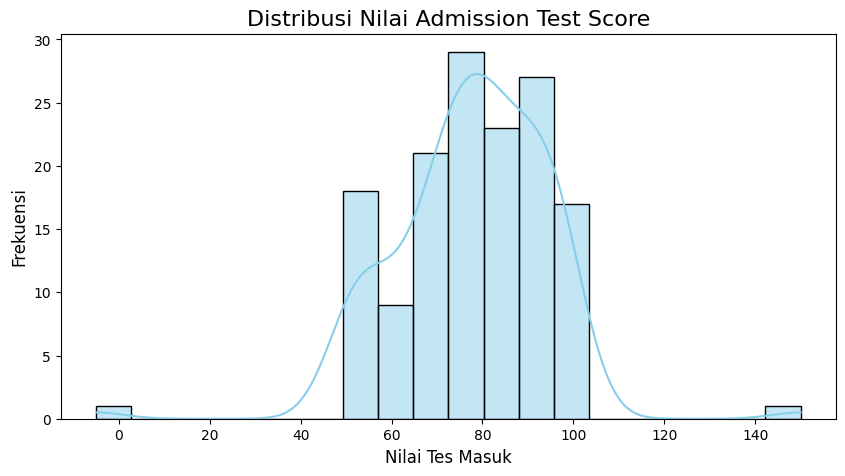

In [6]:
# Visualisasikan dataset dengan histogram
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x='Admission Test Score',
    kde=True, 
    bins=20,
    color='skyblue',
    edgecolor='black'
)

# Tambahkan judul dan label
plt.title('Distribusi Nilai Admission Test Score', fontsize=16)
plt.xlabel('Nilai Tes Masuk', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.show()

#### Berdasarkan histogram Distribusi Nilai Admission Test Score, dapat dijelaskan bahwa sebaran nilai tes masuk mahasiswa menunjukkan pola yang mendekati distribusi normal dengan puncaknya terletak pada kisaran nilai 70-80. Mayoritas mahasiswa memperoleh nilai antara 60 hingga 90, dengan konsentrasi tertinggi mencapai sekitar 25-30 mahasiswa pada rentang nilai tertentu. Distribusi ini terlihat cukup simetris dengan ekor yang memanjang di kedua sisi, mengindikasikan adanya variasi kemampuan mahasiswa dari yang sangat rendah hingga sangat tinggi.

#### Histogram mengungkapkan bahwa tes masuk berhasil menangkap keragaman kemampuan akademik calon mahasiswa. Meskipun sebagian besar terkonsentrasi di level menengah, terdapat beberapa mahasiswa yang menunjukkan performa exceptional dengan nilai di atas 100, sementara sebagian kecil lainnya memperoleh nilai di bawah 40. Pola distribusi yang relatif mulus tanpa celah yang signifikan menunjukkan bahwa instrumen tes tersebut cukup efektif dalam membedakan tingkat kemampuan peserta.

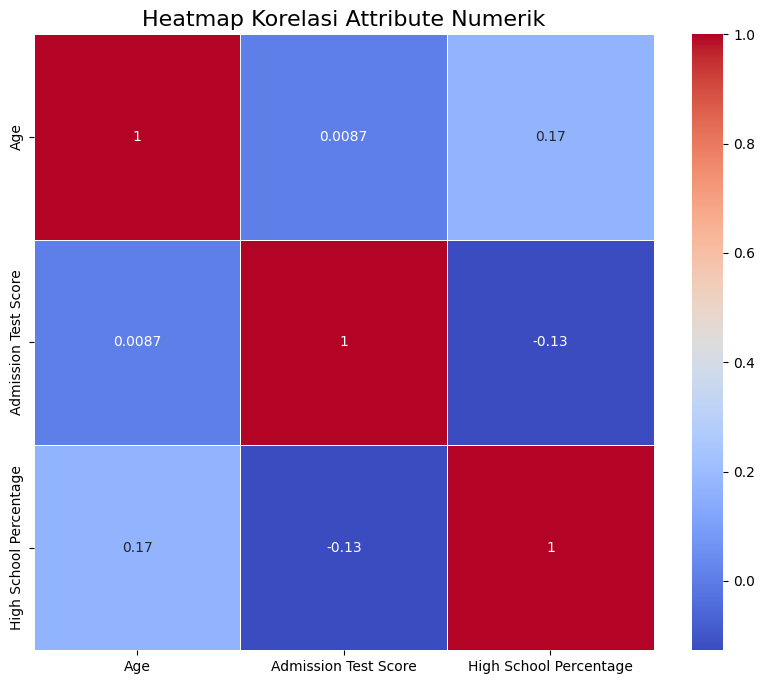

In [7]:
# 6. Tampilkan korelasi dataset menggunakan heatmap.
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Attribute Numerik', fontsize=16)
plt.show()

## Korelasi Sangat Lemah:

1. Age dan Test Score: 0.0087 → hampir nol, tidak ada hubungan
2. Age dan HS Percentage: 0.17 → hubungan positif lemah
3. Test Score dan HS Percentage: -0.13 → hubungan negatif lemah

### Test Score dan HS Percentage seharusnya berhubungan positif (nilai SMA tinggi → test score tinggi), tapi di data ini malah negatif.
### Tidak ada hubungan kuat antara ketiga variabel ini.

# Kesimpulan Analisis Data

1. Dataset ini memiliki total 157 record dan 7 atribut. Dari jumlah atribut tersebut, 3 di antaranya bertipe angka (numerik), sementara 4 sisanya bertipe objek (kategorikal).
2. Data memiliki beberapa nilai yang tidak valid atau logis. Terdapat nilai negatif pada kolom Age, Admission Test Score, dan High School Percentage. Hal ini menunjukkan bahwa data cleaning (pembersihan data) diperlukan sebelum melakukan analisis lebih lanjut. Rata-rata (mean) dan median (50%) dari Admission Test Score dan High School Percentage menunjukkan bahwa sebagian besar data terkonsentrasi di sekitar nilai tengah.

## Distribusi Data (Histogram):
1. Age: Distribusi usia menunjukkan sebaran yang cenderung miring ke kanan (skewed right). Ini berarti sebagian besar mahasiswa berusia muda.
2. Admission Test Score dan High School Percentage: Kedua atribut ini menunjukkan distribusi yang cenderung normal atau menyerupai bentuk lonceng, dengan sebagian besar data terkonsentrasi di sekitar nilai rata-ratanya.

## Korelasi Dataset (Heatmap): 
1. Berdasarkan visualisasi heatmap, hubungan antar atribut numerik sangat lemah. Nilai korelasi terkuat adalah 0.17 antara Age dan High School Percentage. Ini mengindikasikan bahwa tidak ada hubungan linear yang signifikan antara usia, skor tes, dan persentase nilai sekolah.

# POSTTEST 3

Jumlah missing value tiap kolom:
Name         0
Age          0
Gender       0
Initial      0
Age_Group    0
dtype: int64

Jumlah duplicate sebelum: 0
Jumlah duplicate sesudah: 0


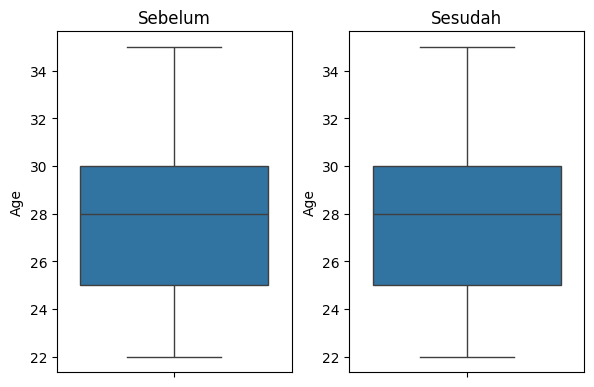

In [55]:
# ================================
# 1. DATA CLEANING
# ================================

# Handling Missing Value
print("Jumlah missing value tiap kolom:")
print(df.isnull().sum())

# hapus baris yang ada missing value
df = df.dropna()

# Handling Duplicate Value
print("\nJumlah duplicate sebelum:", df.duplicated().sum())
df = df.drop_duplicates()
print("Jumlah duplicate sesudah:", df.duplicated().sum())

# Handling Outlier dengan Z-Score
fig, axes = plt.subplots(1,2, figsize=(6,4))
plt.tight_layout()
sns.boxplot(df['Age'], orient='v', ax=axes[0])
axes[0].title.set_text("Sebelum")

# Hapus outlier dengan Z-Score
df = df[(np.abs(stats.zscore(df['Age'])) < 3)]

sns.boxplot(df['Age'], orient='v', ax=axes[1])
axes[1].title.set_text("Sesudah")
plt.show()

## 1. Data Cleaning

Data Cleaning adalah tahap awal dalam preprocessing data yang bertujuan untuk memastikan data **bersih, lengkap, dan bebas dari anomali** sebelum dilakukan analisis atau pemodelan.

### 1.1 Handling Missing Value
- Missing value merupakan data yang hilang pada satu atau beberapa kolom.
- Pada tahap ini, baris yang memiliki missing value dihapus menggunakan `dropna()`.
- Tujuannya agar **tidak terjadi error pada analisis dan model prediksi**, serta menjaga kualitas data.

### 1.2 Handling Duplicate Value
- Duplikasi data dapat menyebabkan **bias pada hasil analisis dan model**.
- Baris duplikat dihapus menggunakan `drop_duplicates()` sehingga setiap entri data menjadi unik.

### 1.3 Handling Outlier
- Outlier adalah nilai ekstrem yang jauh dari distribusi normal data.
- Dihapus menggunakan metode **Z-Score**, dengan batas 3 standar deviasi dari mean.
- Tujuannya untuk **mengurangi pengaruh data ekstrem** yang dapat merusak analisis statistik dan prediksi model.
- Boxplot sebelum dan sesudah penghapusan outlier digunakan untuk **memvisualisasikan efek pembersihan data**.

In [100]:
# ================================
# 2. NORMALISASI & STANDARISASI
# ================================

from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Ambil hanya kolom numerik
num_col_ = df.select_dtypes(include=np.number).columns

# ---- Normalisasi (MinMaxScaler)
scaler_norm = MinMaxScaler()
df_norm = df.copy()
df_norm[num_col_] = scaler_norm.fit_transform(df_norm[num_col_])

print("Data setelah normalisasi (MinMaxScaler):")
print(df_norm[num_col_].head())

# ---- Standarisasi (StandardScaler)
scaler_std = StandardScaler()
df_std = df.copy()
df_std[num_col_] = scaler_std.fit_transform(df_std[num_col_])

print("\nData setelah standarisasi (StandardScaler):")
print(df_std[num_col_].head())

Data setelah normalisasi (MinMaxScaler):
        Age  Admission Test Score  High School Percentage  Score_GPA_Ratio
0  1.000000              0.000000                0.513376         0.104512
1  0.571429              1.000000                0.384712         0.605881
2  0.000000              0.795918                0.649521         0.340285
3  0.000000              0.102041                0.771492         0.060540
4  0.428571              0.306122                0.391012         0.291237

Data setelah standarisasi (StandardScaler):
        Age  Admission Test Score  High School Percentage  Score_GPA_Ratio
0  1.608927             -2.101723               -0.504544        -1.074351
1  0.265667              1.586831               -1.085341         1.704364
2 -1.525346              0.834065                0.110019         0.232361
3 -1.525346             -1.725340                0.660602        -1.318059
4 -0.182086             -0.972574               -1.056905        -0.039474


## 2. Normalisasi & Standarisasi

Tahap ini bertujuan untuk **menyamakan skala fitur numerik** agar perbedaan besaran nilai antar kolom tidak mempengaruhi proses analisis atau pemodelan.

### 2.1 Normalisasi
- Normalisasi mengubah nilai numerik agar **semua berada pada rentang yang sama**, biasanya antara 0 dan 1.
- Digunakan **MinMaxScaler** dari scikit-learn.
- Normalisasi membantu algoritma yang **sensitif terhadap skala**, seperti KNN atau Neural Network, agar tidak bias terhadap nilai yang besar.

### 2.2 Standarisasi
- Standarisasi mengubah nilai numerik sehingga **rata-rata = 0** dan **standar deviasi = 1**.
- Digunakan **StandardScaler** dari scikit-learn.
- Berguna ketika fitur memiliki **unit atau rentang berbeda** sehingga perbedaan skala tidak memengaruhi model.

In [101]:
# ================================
# 3. ENCODING KOLOM KATEGORIKAL
# ================================

# ---- One Hot Encoding (contoh untuk kolom Gender)
if "Gender" in df.columns:
    df = pd.get_dummies(df, columns=["Gender"], drop_first=True)
    print("Hasil One Hot Encoding (Gender):")
    display(df.head())

# ---- Ordinal Encoding (contoh untuk kolom Initial)
from sklearn.preprocessing import OrdinalEncoder

if "Initial" in df.columns:
    encoder = OrdinalEncoder()
    df["Initial"] = encoder.fit_transform(df[["Initial"]])
    print("Hasil Ordinal Encoding (Initial):")
    display(df.head())

Hasil One Hot Encoding (Gender):


,Name,Age,Admission Test Score,High School Percentage,City,Admission Status,Age_Group,Score_GPA_Ratio,Gender_Male
0,Shehroz,24.0,50.0,68.900,Quetta,Rejected,Mahasiswa,0.715308,False
1,Waqar,21.0,99.0,60.730,Karachi,Rejected,Mahasiswa,1.603758,False
2,Bushra,17.0,89.0,77.545,Islamabad,Accepted,Remaja,1.133108,True
3,Aliya,17.0,55.0,85.290,Karachi,Rejected,Remaja,0.637386,True
4,Bilal,20.0,65.0,61.130,Lahore,Rejected,Mahasiswa,1.046193,True


## 3. Encoding Kolom Kategorikal

Tahap ini bertujuan untuk **mengubah data kategorikal menjadi format numerik** agar dapat diproses oleh algoritma machine learning, karena sebagian besar algoritma hanya menerima input numerik.

### 3.1 One Hot Encoding
- Digunakan untuk kolom kategorikal **tanpa urutan** (nominal), misal `Gender`.
- Setiap kategori diubah menjadi **kolom biner** (0 atau 1).
- `drop_first=True` digunakan untuk menghindari **dummy variable trap**, yaitu kolom yang terlalu banyak dan redundan.
- Contoh: kolom `Gender` dengan nilai `Male` dan `Female` akan menjadi satu kolom `Gender_Male` (1 jika Male, 0 jika Female).

### 3.2 Ordinal Encoding
- Digunakan untuk kolom kategorikal **yang memiliki urutan** (ordinal), misal `Initial` atau level pendidikan.
- Setiap kategori diubah menjadi **angka sesuai urutan**.
- Misal: `Low`, `Medium`, `High` → 0, 1, 2.
- Digunakan `OrdinalEncoder` dari scikit-learn.

In [102]:
# ================================
# 4. FEATURE ENGINEERING
# ================================
# contoh: bikin kategori umur (kalau ada kolom Age)
if "Age" in df.columns:
    bins = [0, 18, 25, 35, 50, 100]
    labels = ["Remaja", "Mahasiswa", "Dewasa Muda", "Dewasa", "Lansia"]
    df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

# contoh lain: rasio skor tes dengan nilai sekolah
if "Admission Test Score" in df.columns and "High School Percentage" in df.columns:
    df["Score_GPA_Ratio"] = df["Admission Test Score"] / (df["High School Percentage"] + 1)

print("\nFeature baru berhasil ditambahkan (5 baris teratas):")
print(df.head())


Feature baru berhasil ditambahkan (5 baris teratas):
      Name   Age  Admission Test Score  High School Percentage       City  \
0  Shehroz  24.0                  50.0                  68.900     Quetta   
1    Waqar  21.0                  99.0                  60.730    Karachi   
2   Bushra  17.0                  89.0                  77.545  Islamabad   
3    Aliya  17.0                  55.0                  85.290    Karachi   
4    Bilal  20.0                  65.0                  61.130     Lahore   

  Admission Status  Age_Group  Score_GPA_Ratio  Gender_Male  
0         Rejected  Mahasiswa         0.715308        False  
1         Rejected  Mahasiswa         1.603758        False  
2         Accepted     Remaja         1.133108         True  
3         Rejected     Remaja         0.637386         True  
4         Rejected  Mahasiswa         1.046193         True  


## 4. Feature Engineering

Feature Engineering adalah tahap untuk **membuat fitur baru dari data yang sudah ada** agar model bisa belajar lebih efektif dan informasi dari data lebih maksimal.

### 4.1 Membuat Kategori Umur
- Dari kolom `Age`, dibuat **kelompok umur** (`Age_Group`) menggunakan `pd.cut()`.
- Tujuannya agar model bisa **mengelompokkan individu berdasarkan rentang usia**.
- Contoh kategori:
  - 0–18 → Remaja  
  - 19–25 → Mahasiswa  
  - 26–35 → Dewasa Muda  
  - 36–50 → Dewasa  
  - >50 → Lansia

### 4.2 Membuat Rasio Skor Tes dengan Nilai Sekolah
- Dari kolom `Admission Test Score` dan `High School Percentage`, dibuat fitur baru `Score_GPA_Ratio`.
- Tujuannya untuk **menggabungkan informasi dua kolom menjadi satu fitur** yang merepresentasikan performa relatif siswa.

In [103]:
# ================================
# 5. SPLITTING DATA (sesuai modul)
# ================================

target_col = "Admission Test Score" 

# fitur dan target
X = df.drop(columns=[target_col])
y = df[target_col]

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Dimensi X_train:", X_train.shape)
print("Dimensi X_test :", X_test.shape)
print("Dimensi y_train:", y_train.shape)
print("Dimensi y_test :", y_test.shape)


Dimensi X_train: (120, 8)
Dimensi X_test : (30, 8)
Dimensi y_train: (120,)
Dimensi y_test : (30,)


## 5. Splitting Data

Tahap ini bertujuan untuk **memisahkan dataset menjadi data training dan data testing** agar model dapat dilatih dan dievaluasi secara objektif.

### 5.1 Menentukan Target dan Fitur
- `target_col` adalah kolom yang ingin diprediksi, dalam kasus ini `Admission Test Score`.
- `X` berisi **semua fitur kecuali target**.
- `y` berisi **target yang akan diprediksi**.

### 5.2 Membagi Dataset
- Dataset dibagi menjadi:
  - **Training set (80%)** → digunakan untuk **melatih model**.
  - **Testing set (20%)** → digunakan untuk **mengukur performa model pada data baru**.
- Fungsi `train_test_split()` dari scikit-learn digunakan untuk membagi data secara acak.
- `random_state=42` memastikan **hasil split dapat direproduksi**.

### 5.3 Informasi Dimensi Data
- `X_train` dan `y_train` → data untuk pelatihan model.
- `X_test` dan `y_test` → data untuk pengujian model.
- Menampilkan dimensi membantu memastikan **proporsi split sudah sesuai**.